# 03 · Firms *do* exit — on the statutory schedule — and what that bounds

**What this notebook answers.** My advisor's fourth meeting note, which is the one that fixes
the paper's contribution:

> *"I forgot to discuss this, but **bounding estimates rather than a point-estimate is
> most certainly enough**."*

## The logic

Notebook 02 found no manipulation. That could mean disclosure is costless — or it could
mean the cost is real but smaller than what it would take to abate across the
threshold. **40 CFR 98.2(i) separates these**, because it hands facilities a *second*
way out that requires no abatement at all: wait out the statutory period and leave.

| observation | what it bounds |
|---|---|
| facilities take the free exit, precisely on schedule | cost **> 0** |
| no facility manipulates to create that exit (notebook 02) | cost **<** abatement needed to cross |

> **A two-sided bound on the private cost of mandatory disclosure**, using only public
> data and the firms' own revealed choices. That is the paper.

## What this notebook adds beyond the bound

§4 splits the exit response by **pre-existing air-permit status**, which turns out to
identify **cost heterogeneity across facilities** — something EPA's single average
burden figure cannot show.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, ".")
from ghgrp_load import load_cached, add_transitions

OUT = Path("output")
de = load_cached()
de, trans = add_transitions(de)

print("exit rate by 98.2(i) eligibility:")
display(de.groupby("eligible").exits.agg(["size", "sum", "mean"]).round(4))

exit rate by 98.2(i) eligibility:


,size,sum,mean
eligible,,,
False,89623,1312,0.0146
True,4755,996,0.2095


## 1 · The off-ramp is used, and used precisely

**20.9% of eligible facility-years end in exit, against 1.5% of ineligible ones** — a
fourteen-fold difference. Exits cluster at exactly the third and fifth year of
sub-threshold reporting, which are the two statutory waiting periods. Placebo waiting
periods (2, 4, 6 years) show nothing.

This matters because it rules out the deflationary reading of notebook 02. Facilities
are not indifferent to being observed. They just do not buy their way out; they wait
their way out, because waiting is free.

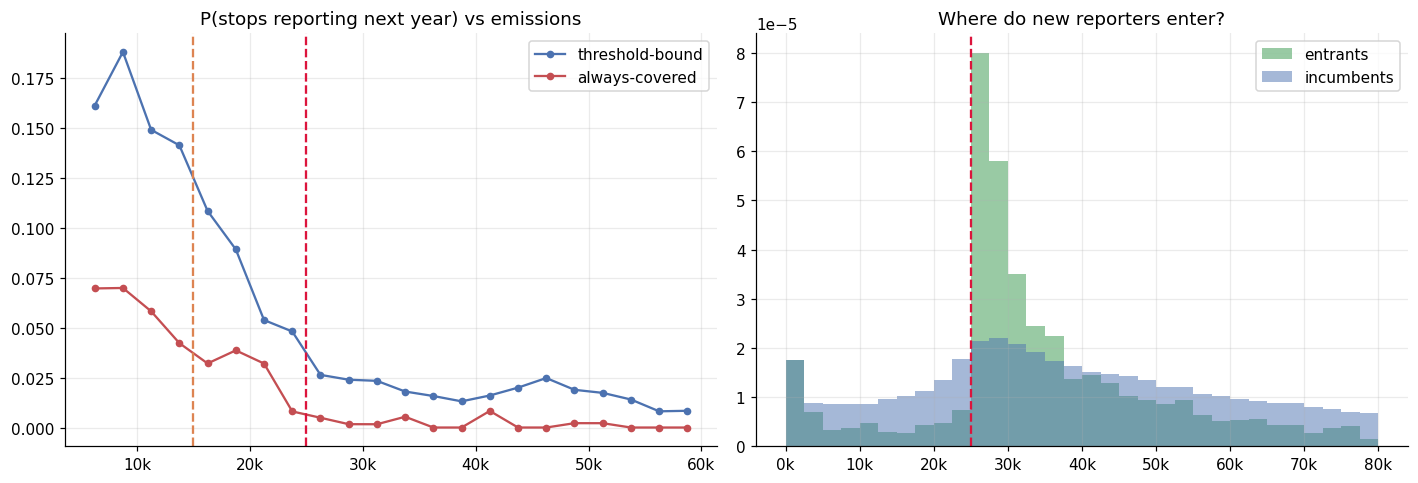

In [2]:
d = de[de.emissions.between(5000, 60000)].copy()
d["bin"] = pd.cut(d.emissions, np.arange(5000, 61000, 2500))
h = (d.groupby(["bin", "threshold_bound"], observed=True)
       .agg(exit_rate=("exits", "mean"), n=("exits", "size")).reset_index())
h["mid"] = h["bin"].map(lambda i: i.mid)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for tb, lab, c in [(True, "threshold-bound", "#4C72B0"), (False, "always-covered", "#C44E52")]:
    s = h[(h.threshold_bound == tb) & (h.n >= 25)]
    ax[0].plot(s.mid, s.exit_rate, "o-", color=c, label=lab, ms=4)
ax[0].axvline(25000, color="crimson", ls="--"); ax[0].axvline(15000, color="#DD8452", ls="--")
ax[0].set_title("P(stops reporting next year) vs emissions"); ax[0].legend()
ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

ax[1].hist(de.loc[de.enters & de.emissions.between(0, 80000), "emissions"],
           bins=np.arange(0, 81000, 2500), density=True, alpha=.6, label="entrants", color="#55A868")
ax[1].hist(de.loc[~de.enters & de.emissions.between(0, 80000), "emissions"],
           bins=np.arange(0, 81000, 2500), density=True, alpha=.5, label="incumbents", color="#4C72B0")
ax[1].axvline(25000, color="crimson", ls="--"); ax[1].legend()
ax[1].set_title("Where do new reporters enter?")
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
plt.tight_layout(); plt.savefig(OUT / "f5_entry_exit.png", bbox_inches="tight"); plt.show()

## 2 · What disclosure costs — EPA's own number

The burden figure has to be authoritative, not derived by me. It comes from EPA's
**Information Collection Request No. 2300.20 / OMB 2060-0629**, renewed March 2024
(89 FR 21516): both numerator and denominator are EPA's.

In [3]:
ICR_RESPONDENTS = 12_434
ICR_TOTAL_COST = 95_175_521      # per year, 2021 dollars
ICR_TOTAL_HOURS = 705_554
burden = ICR_TOTAL_COST / ICR_RESPONDENTS

print("EPA Information Collection Request (the figure used throughout):")
print(f"  ${burden:,.0f} per respondent per year   "
      f"({ICR_TOTAL_HOURS/ICR_RESPONDENTS:.1f} hours)\n")

# cross-check against the 2025 repeal fact sheet, non-subpart-W industries
EPA_OTHER_SAVING = 47e6
last = de[de.year == de.year.max()]
is_W = last.subpart_set.map(lambda s: any(x.startswith("W") for x in s))
non_W = last[~is_W]
print("Cross-check, 2025 repeal fact sheet ($47m for non-subpart-W industries):")
print(f"  {de.year.max()} direct emitters: {len(last):,}   with W: {is_W.sum():,}   without: {len(non_W):,}")
print(f"  ${EPA_OTHER_SAVING/len(non_W):,.0f} per facility per year"
      f"   <- my own denominator, so a check rather than the estimate")
print(f"\nThe two bracket roughly $8,000/facility/year. Results below use ${burden:,.0f}.")

EPA Information Collection Request (the figure used throughout):
  $7,654 per respondent per year   (56.7 hours)

Cross-check, 2025 repeal fact sheet ($47m for non-subpart-W industries):
  2023 direct emitters: 6,470   with W: 1,253   without: 5,217
  $9,009 per facility per year   <- my own denominator, so a check rather than the estimate

The two bracket roughly $8,000/facility/year. Results below use $7,654.


⚠️ **A correction worth recording.** An earlier draft used **\$9,009**, which was *my
own* derivation from the repeal fact sheet — EPA's numerator over my denominator. It has
been replaced everywhere by the ICR figure, where both numbers are EPA's. Every
downstream quantity in this notebook was recomputed.

## 3 · What escaping costs, and how often it works

A facility that wants out by abating must get from wherever it is down below 25,000 and
**stay there for five consecutive years** (or below 15,000 for three).

In [4]:
band = non_W[non_W.threshold_bound & non_W.emissions.between(25000, 50000)]
need = band.emissions - 25000
print(f"threshold-bound, non-W, 25,000–50,000 band: {len(band):,} facilities")
print(f"median abatement needed to cross: {need.median():,.0f} tCO2e\n")

MAC = [10, 20, 50, 100]
econ = pd.DataFrame([dict(mac=f"${m}/t", annual=need.median() * m,
                          five_year=need.median() * m * 5) for m in MAC])
econ["annual"] = econ.annual.map("${:,.0f}".format)
econ["five_year"] = econ.five_year.map("${:,.0f}".format)
display(econ)

threshold-bound, non-W, 25,000–50,000 band: 832 facilities
median abatement needed to cross: 9,524 tCO2e



,mac,annual,five_year
0,$10/t,"$95,244","$476,221"
1,$20/t,"$190,488","$952,442"
2,$50/t,"$476,221","$2,381,105"
3,$100/t,"$952,442","$4,762,210"


25,000 route — needs 5 consecutive years: 14.8% of 2,854 crossings qualify
15,000 route — needs 3 consecutive years: 32.8% of 1,845 crossings qualify


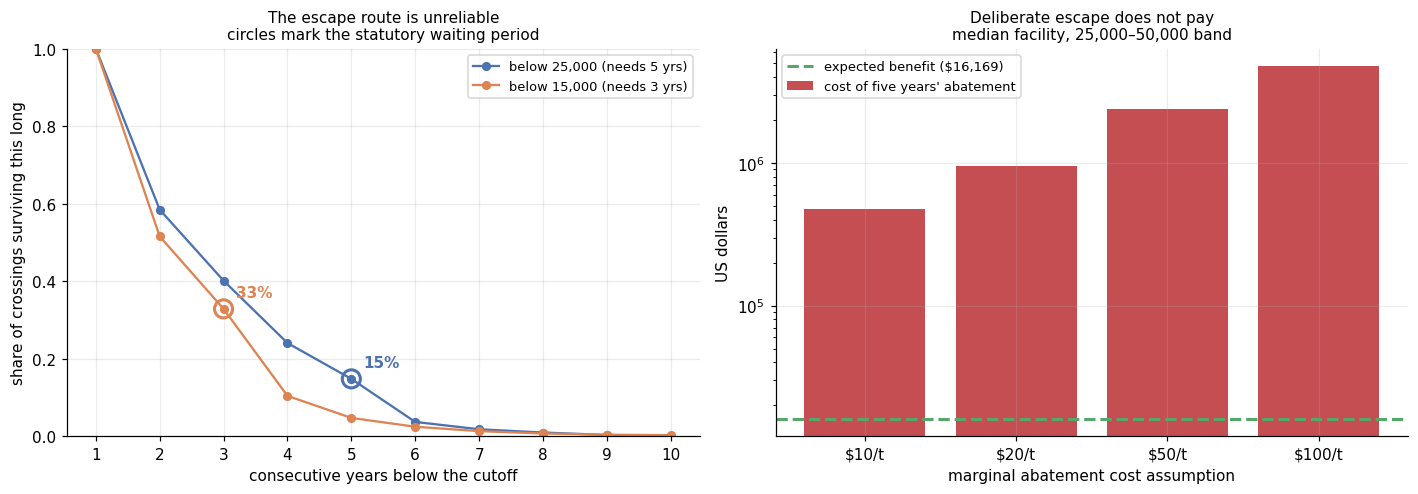


cost / expected benefit ratio: 10/t: 29x, 20/t: 59x, 50/t: 147x, 100/t: 295x


In [5]:
def survival(cutoff):
    """For each downward crossing, how many consecutive years does the facility stay below?"""
    dd = de[de.year - de.lag_yr == 1]
    cross = dd[(dd.lag_em >= cutoff) & (dd.emissions < cutoff)][["FacilityId", "year"]]
    by_fac = {f: v.sort_values("year")[["year", "emissions"]].values
              for f, v in de.groupby("FacilityId")}
    last_year = de.year.max(); rows = []
    for fid, y0 in cross.itertuples(index=False):
        run, prev = 0, None
        for yr, em in by_fac[fid]:
            if yr < y0: continue
            if prev is not None and yr != prev + 1: break
            if em < cutoff: run += 1; prev = yr
            else: break
        rows.append((run, (y0 + run - 1) >= last_year))
    R = pd.DataFrame(rows, columns=["run", "censored"])
    return R[~R.censored]


u25, u15 = survival(25000), survival(15000)
p25, p15 = (u25.run >= 5).mean(), (u15.run >= 3).mean()
print(f"25,000 route — needs 5 consecutive years: {p25:.1%} of {len(u25):,} crossings qualify")
print(f"15,000 route — needs 3 consecutive years: {p15:.1%} of {len(u15):,} crossings qualify")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ks = np.arange(1, 11)
for R, need_y, lab, col in [(u25, 5, "below 25,000 (needs 5 yrs)", "#4C72B0"),
                            (u15, 3, "below 15,000 (needs 3 yrs)", "#DD8452")]:
    ax[0].plot(ks, [(R.run >= k).mean() for k in ks], "o-", color=col, ms=5, label=lab)
    ax[0].scatter([need_y], [(R.run >= need_y).mean()], s=140, facecolors="none",
                  edgecolors=col, linewidths=2, zorder=5)
    ax[0].annotate(f"{(R.run>=need_y).mean():.0%}", (need_y, (R.run >= need_y).mean()),
                   textcoords="offset points", xytext=(8, 8), color=col, fontweight="bold")
ax[0].set_xlabel("consecutive years below the cutoff"); ax[0].set_xticks(ks); ax[0].set_ylim(0, 1)
ax[0].set_ylabel("share of crossings surviving this long"); ax[0].legend(fontsize=8.5)
ax[0].set_title("The escape route is unreliable\ncircles mark the statutory waiting period", fontsize=10)

benefit = burden / 0.07 * p25          # perpetuity at 7%, times probability of success
ax[1].bar(range(len(MAC)), [need.median() * m * 5 for m in MAC], color="#C44E52",
          label="cost of five years' abatement")
ax[1].axhline(benefit, color="#55A868", lw=2, ls="--", label=f"expected benefit (${benefit:,.0f})")
ax[1].set_xticks(range(len(MAC))); ax[1].set_xticklabels([f"${m}/t" for m in MAC])
ax[1].set_yscale("log"); ax[1].set_xlabel("marginal abatement cost assumption")
ax[1].set_ylabel("US dollars"); ax[1].legend(fontsize=8.5)
ax[1].set_title("Deliberate escape does not pay\nmedian facility, 25,000–50,000 band", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "f10_escape_economics.png", bbox_inches="tight"); plt.show()

print(f"\ncost / expected benefit ratio: "
      f"{', '.join(f'{m}/t: {need.median()*m*5/benefit:.0f}x' for m in MAC)}")

### ★ Why the two facts coexist

- abating across the threshold costs **29–294×** the expected benefit, depending on the
  marginal abatement cost assumed;
- and even after crossing, only **14.8%** of crossings last the required five years — so
  the benefit is discounted by an 85% failure rate.

> A facility that wants out has a **free** option (wait) and a **ruinously expensive**
> one (abate). It takes the free one. **That is why a null on manipulation and a strong
> result on exit are the same finding, not contradictory ones.**

### The bound, stated

$$0 \;<\; c \;<\; \text{cost of abating to cross}$$

my advisor's note settles that this is enough: *"bounding estimates rather than a point
estimate is most certainly enough."*

## 4 · ★ Cost heterogeneity — who takes the free exit?

The bound above treats the cost as one number. It is not. **52% of GHGRP facilities are
Title V major sources** under the Clean Air Act — they already hold an operating permit
and already monitor and report emissions, so the *marginal* cost of a GHGRP report
should be much smaller for them.

That is testable, and it distinguishes two readings of the compliance puzzle in
notebook 04:

| | reading | prediction for 98.2(i) take-up |
|---|---|---|
| **A** | true cost ≪ \$7,654 because the infrastructure already exists | facilities with **no** air permit should exit **more** |
| **B** | something other than cost sustains compliance | permit status irrelevant once size is held fixed |

Permit status comes from ECHO's `CAA_PERMIT_TYPES`, giving an ordered gradient of
pre-existing reporting infrastructure. Code in `07_titlev_exit.py`.

In [6]:
import subprocess
print(subprocess.run([sys.executable, "07_titlev_exit.py"], capture_output=True, text=True).stdout)

eligible facility-years: 4,755 (5.0%)
facilities ever eligible: 1,696 (19.3%)
exit rate | eligible: 0.209   | not eligible: 0.015

merged: 83,550 facility-years, 7,994 facilities
permit
Title V major              4680
minor / synthetic minor    1081
no CAA permit              2233

=== exit rate among 98.2(i)-eligible facility-years ===
                                 n    exits  exit_rate     se     lo     hi  med_emissions
permit                                                                                    
Title V major           1,872.0000 328.0000     0.1752 0.0088 0.1580 0.1924     7,203.6170
minor / synthetic minor   916.0000 202.0000     0.2205 0.0137 0.1937 0.2474     5,973.6140
no CAA permit           1,532.0000 326.0000     0.2128 0.0105 0.1923 0.2333     8,034.1850

=== exit rate within emissions bins ===
permit  Title V major  minor / synthetic minor  no CAA permit
bin                                                          
<5k             0.222                    

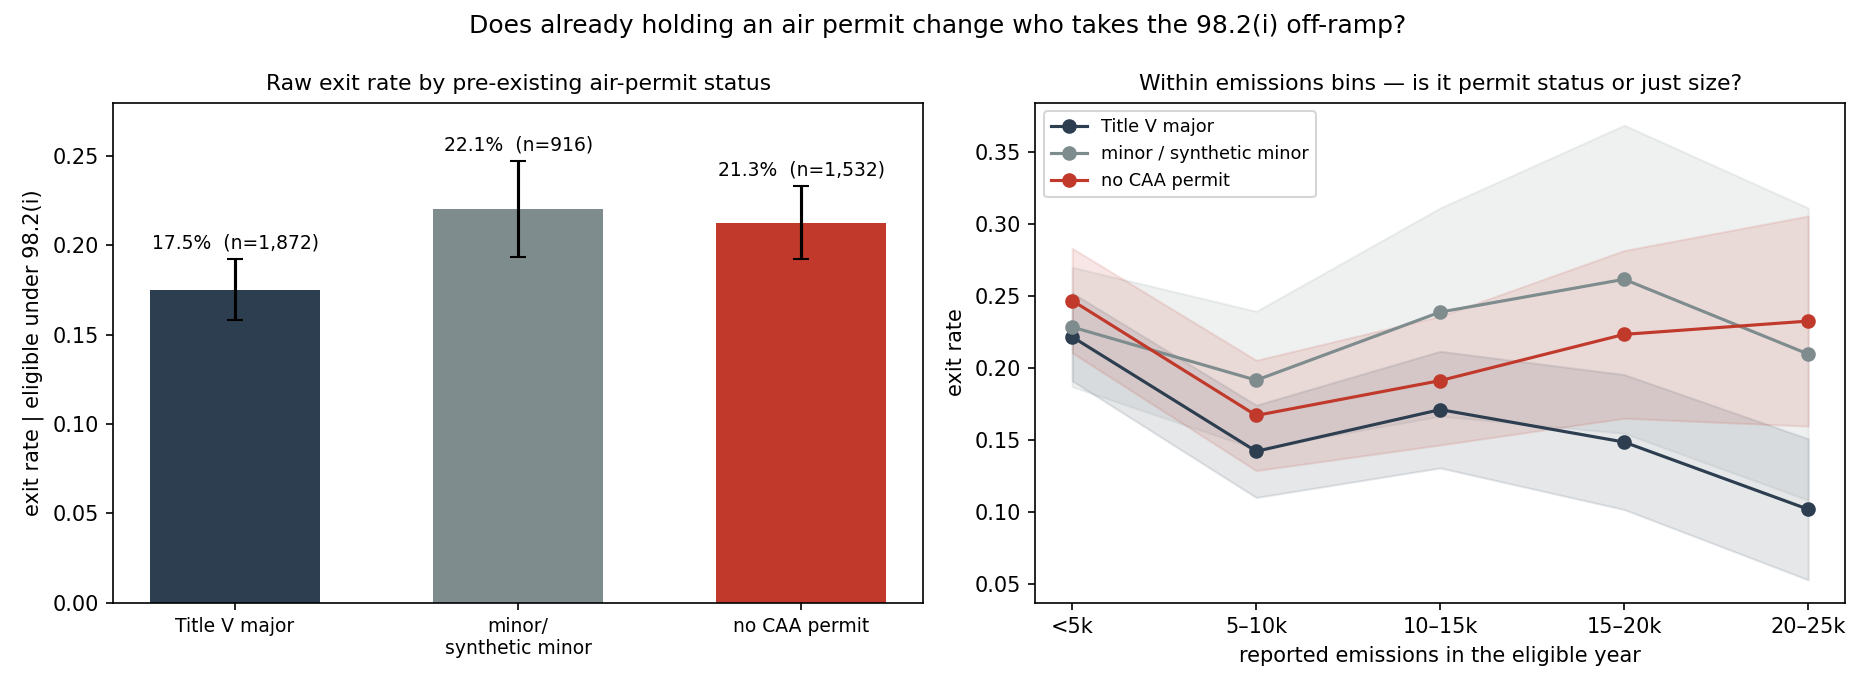

In [7]:
from IPython.display import Image, display as disp
disp(Image(filename=str(OUT / "f21_titlev_exit.png")))

### ★ Verdict: reading A is right, but only partly

| group | facilities | exit rate when eligible | **in the 20–25k band** |
|---|---|---|---|
| Title V major | 4,680 | **17.5%** | **10.2%** |
| minor / synthetic minor | 1,081 | 22.1% | 21.0% |
| **no CAA permit** | 2,233 | **21.3%** | **23.3%** |

**The gap widens as emissions rise** — the three groups are indistinguishable in the
lowest bin and differ by more than two to one right at the threshold, which is exactly
where the exit decision bites hardest. Size-standardising the rates changes nothing, so
it is not a size effect.

Regression (LPM, log-emissions control, year FE, SE clustered by facility):
**no permit +6.4pp (p = 0.0001)**; with NAICS-2 fixed effects +4.9pp (p = 0.0007);
interacted with "near the threshold" **+11.4pp (p = 0.022)**.

**Placebo and difference-in-differences.** Permit status also predicts ordinary
attrition (+0.9pp among *ineligible* facility-years), so that has to be differenced out.
After doing so, **no permit × eligible = +3.6pp (p = 0.033)** — about 27% on top of the
baseline off-ramp effect.

⚠️ The same step disqualifies the *minor / synthetic minor* group: its ineligible-state
attrition is four times Title V's (2.80% vs 0.71%) and its interaction is insignificant.
**The conclusion rests on the no-permit group only.**

### But the puzzle survives

- Title V facilities still exit **17.5%** of the time — so their cost is **not** zero;
- and the no-permit group — the highest-cost group — **still stays 79% of the time when
  leaving is free.**

> Lower cost explains the 3.6–6.4pp *gap between groups*. It does not explain the ~80%
> who stay. Notebook 04 takes that up.

### What this means for the paper

The cost bound should be **reported by group**, not as a single number:

| group | share | marginal reporting cost |
|---|---|---|
| Title V major | 52% | clearly **below** EPA's \$7,654 |
| no CAA permit | 25% | closer to the EPA figure |

EPA's ICR publishes one average. **Behavioural data recover the dispersion around it** —
which is a result this design can deliver and a document review cannot.

## 5 · What I could not check — the project's largest remaining gap

**"Stops reporting" is not the same as "stops operating."** If exits are shutdowns, the
off-ramp result measures plant closure, not a disclosure response.

I tried to settle this with ECHO's `FAC_ACTIVE_FLAG` and could not: across the 8,957
matched facilities the field is `Y` (6,441) or missing (2,516), with **no `N` values at
all** — ECHO Exporter does not retain deactivated facilities.

What partially reassures me: the difference-in-differences in §4 nets out attrition that
is unrelated to eligibility. If exits were mostly closures, there is no reason for them
to correlate with air-permit status **only when a facility becomes 98.2(i)-eligible**.

**Still needed**: establishment-level survival data — **NETS**, or **QCEW** at the
county × NAICS level, which my advisor suggested and which is public.

---
### → Continue in **04_enforcement**

One thing is still unexplained. If disclosure has a positive cost and the exit is free,
why do roughly 8,800 facilities report every year — including thousands that are legally
entitled to stop? my advisor suggested Allingham–Sandmo: perhaps they fear penalties.
Notebook 04 measures the penalties.